<div class="cover">

# Lab 1 — Introduction to Natural Language Processing

**Name:** Hadi Muneer Abu Allairat<br>
**Student ID:** 2230005761<br>
**Dataset:** IMDB Dataset of 50K Movie Reviews

</div>


**Task 1.** Search online for one of the different dataset types (CSV, text, JSON, SQL, HTML, PDF, DOCX).

**Task 2.** Download and open the dataset.

I picked **CSV**, and the dataset is the *IMDB Dataset of 50K Movie Reviews* from Kaggle
(`lakshmi25npathi/imdb-dataset-of-50k-movie-reviews`).

## Task 1 — Choosing a format

The seven formats from the lecture are not interchangeable; each one trades structure against
convenience:

| Format | Structure | Typical NLP use |
| --- | --- | --- |
| CSV | flat table, one row per document | labelled corpora for classification |
| Text | none | raw corpora for language modelling |
| JSON | nested | API dumps, tweets, documents with metadata |
| SQL | relational | corpora too large to hold in memory |
| HTML | markup | web scraping, needs tag stripping |
| PDF | layout, not text | reports; extraction is lossy |
| DOCX | markup + styling | documents that come from people, not machines |

CSV is the right choice here because the task the corpus is built for — sentiment classification —
is exactly *text plus one label*, which is a two-column table. Nothing about the data is nested, so
JSON would only add parsing overhead, and 50,000 rows sits comfortably in memory, so SQL would be
premature.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("data")
pd.set_option("display.max_colwidth", 120)

## Task 2 — Downloading and opening the dataset

The Kaggle copy is what `kagglehub` fetches. Re-running the download on every execution is wasteful,
so the cell below only downloads when the local copy is missing.

In [2]:
csv_path = DATA_DIR / "IMDB Dataset.csv"

if not csv_path.exists():
    import kagglehub

    cache = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    csv_path = Path(cache) / "IMDB Dataset.csv"

print("Reading:", csv_path)
df = pd.read_csv(csv_path)
df.shape

Reading: data\IMDB Dataset.csv


(50000, 2)

In [3]:
df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as ...",positive
1,A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and g...,positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fightin...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portr...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


Both columns come back as `object`, which is what pandas calls "a column of Python strings". The
782 KB memory figure is misleading — it counts the pointers, not the strings themselves. The real
cost is closer to the file size:

In [5]:
print(f"Reported by info(): {df.memory_usage().sum() / 1e6:.1f} MB")
print(f"Including strings:  {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"File on disk:       {csv_path.stat().st_size / 1e6:.1f} MB")

Reported by info(): 0.8 MB
Including strings:  70.9 MB
File on disk:       66.2 MB


### Sanity checks

Before trusting a dataset it is worth asking three questions: are there missing values, are there
duplicates, and are the classes balanced?

In [6]:
print("Missing values per column:")
print(df.isna().sum(), end="\n\n")

print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate review texts:", df["review"].duplicated().sum())

Missing values per column:
review       0
sentiment    0
dtype: int64



Exact duplicate rows: 418


Duplicate review texts: 418


In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Two observations:

- No missing values, which is unusual for scraped text and suggests the Kaggle author already
  cleaned the set.
- There are a few hundred duplicated reviews. They are not harmful for an exploratory lab, but if
  this set were split into train and test *after* the duplicates, the same review could land on both
  sides and inflate the reported accuracy. That is a leak worth remembering for Lab 4.
- The classes are exactly balanced at 25,000 / 25,000. A balanced set means plain accuracy is a
  meaningful metric here, and that the majority-class baseline is 50%.

In [8]:
df = df.drop_duplicates(subset="review").reset_index(drop=True)
print("Rows after dropping duplicate reviews:", len(df))
print(df["sentiment"].value_counts().to_dict())

Rows after dropping duplicate reviews: 49582
{'positive': 24884, 'negative': 24698}


### How long are the reviews?

Review length drives almost every practical decision later on — vocabulary size, truncation limits,
how expensive tokenisation will be.

In [9]:
lengths = df["review"].str.split().str.len()
lengths.describe().round(1)

count    49582.0
mean       231.4
std        171.5
min          4.0
25%        126.0
50%        173.0
75%        281.0
max       2470.0
Name: review, dtype: float64

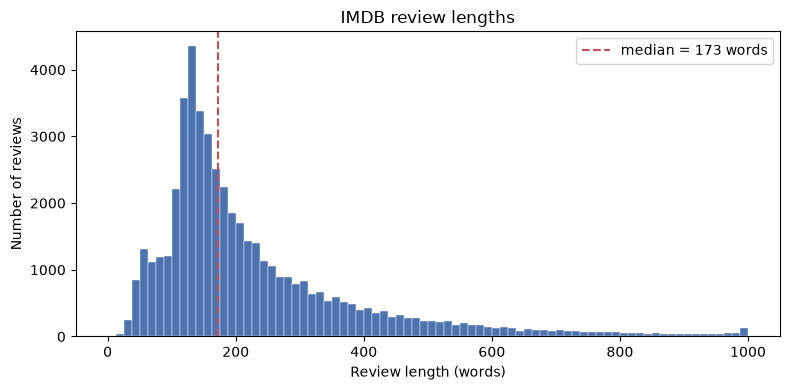

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=80, range=(0, 1000), color="#4c72b0", edgecolor="white", linewidth=0.3)
ax.axvline(lengths.median(), color="#c44e52", linestyle="--", label=f"median = {lengths.median():.0f} words")
ax.set_xlabel("Review length (words)")
ax.set_ylabel("Number of reviews")
ax.set_title("IMDB review lengths")
ax.legend()
plt.tight_layout()
plt.show()

The distribution has a long right tail: the median review is around 170 words but the longest run
past 2,000. A model with a fixed input length would have to truncate the tail, and a bag-of-words
model would let those long reviews dominate raw word counts — which is one of the reasons TF-IDF
normalises by document length.

### Looking at the raw text

"Opening the dataset" is not finished at `head()`. The interesting part is what the strings actually
contain.

In [11]:
print(df.loc[1, "review"])

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.


In [12]:
import re

html_breaks = df["review"].str.contains("<br />").sum()
print(f"Reviews containing '<br />': {html_breaks:,} ({html_breaks / len(df):.1%})")
print("Reviews containing any HTML tag:", df["review"].str.contains(r"<[^>]+>", regex=True).sum())
print("Reviews containing a URL:", df["review"].str.contains(r"https?://", regex=True).sum())

Reviews containing '<br />': 28,966 (58.4%)
Reviews containing any HTML tag: 28968
Reviews containing a URL: 119


Close to 60% of the reviews carry `<br />` tags left over from the scrape. Tokenised as-is, `br` would
become one of the most frequent "words" in the corpus — a token that means nothing and appears
everywhere.

This is the concrete motivation for Lab 2: text that looks clean in a dataframe preview is usually
not clean enough to feed a model.

In [13]:
sample = df.loc[1, "review"]
cleaned = re.sub(r"<[^>]+>", " ", sample)
cleaned = re.sub(r"\s+", " ", cleaned).strip()
print(cleaned[:400])

A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary e


### The same data in another format

To show the trade-off from Task 1 concretely, here is a slice of the corpus written out as JSON and
read back. The content is identical; what changes is that JSON carries its own schema and CSV does
not.

In [14]:
import json

slice_ = df.head(3).to_dict(orient="records")
as_json = json.dumps(slice_, indent=2)
print(as_json[:400], "...")

back = pd.DataFrame(json.loads(as_json))
print("\nRound-trip matches original:", back["review"].tolist() == df.head(3)["review"].tolist())

[
  {
    "review": "One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no pu ...

Round-trip matches original: True


## Summary

- **Task 1:** chose CSV, because the corpus is a flat text-plus-label table.
- **Task 2:** loaded the IMDB 50K review set, 49,582 unique reviews split exactly 50/50 between
  positive and negative.
- The reviews are long (median ~170 words, heavy right tail) and contain leftover HTML, so the next
  step is the preprocessing pipeline from Lab 2.